In [2]:

import sys
import os
sys.path.append(os.path.abspath('..'))

import lightkurve as lk
import transitleastsquares as tls
import matplotlib.pyplot as plt
from utils.data_io import load_csv


/mnt/c/Users/isal7/OneDrive/Área de Trabalho/TCC/neural-network-exoplanet-hunter/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [ ]:
import sys
import os

project_root = os.path.abspath(os.path.join('..'))
if project_root not in sys.path:
    sys.path.append(project_root)


from utils.data_io import load_csv

In [ ]:
TEMPLATE_CSV = "../data/raw/koi_template.csv"
df = load_csv(TEMPLATE_CSV) 

df.head()
Kic_id = 11904151 

ok ok ../data/raw/koi_template.csv


A procurar dados para KIC 11904151...
A baixar os dados (isto pode demorar um pouco)...
Dados brutos carregados e limpos!


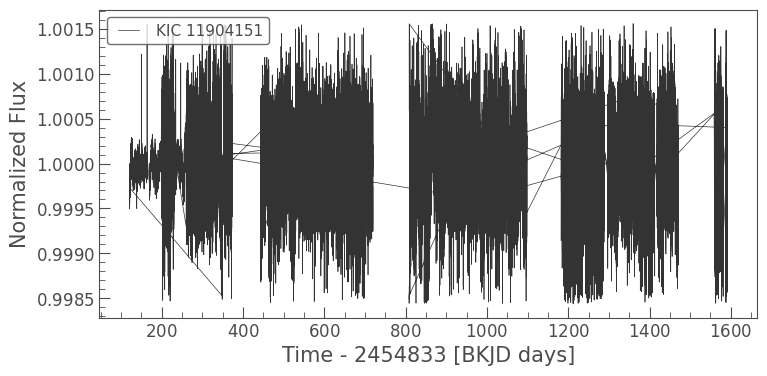

In [ ]:

print(f"A procurar dados para KIC {Kic_id}...")
search_result = lk.search_lightcurve(f'KIC {Kic_id}', author='Kepler')


print("A baixar os dados (isto pode demorar um pouco)...")
lc_collection = search_result.download_all()


lc_bruta = lc_collection.stitch().remove_nans().remove_outliers()

print("Dados brutos carregados e limpos!")
lc_bruta.plot();

In [ ]:
print("A rodar o TLS para encontrar o período...")

model = tls.transitleastsquares(lc_bruta.time.value, lc_bruta.flux.value)


results = model.power(n_threads=4)

print(f"Período encontrado: {results.period:.5f} dias")
print(f"Força do sinal (SDE): {results.SDE:.2f}")


print(f"Disparidade Par-Ímpar (odd_even_mismatch): {results.odd_even_mismatch:.2f}")

A rodar o TLS para encontrar o período...


/mnt/c/Users/isal7/OneDrive/Área de Trabalho/TCC/neural-network-exoplanet-hunter/.venv/lib/python3.12/site-packages/transitleastsquares/validate.py:57: UserWarning: Ignoring unknown parameter: n_threads
  warnings.warn(text)


Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 66 durations
Searching 1476726 data points, 187933 periods from 0.602 to 735.236 days
Using all 12 CPU threads


  0%|          | 7/187933 periods | 00:43<314:47:56

In [ ]:
print(f"A 'dobrar' os dados no período de {results.period:.5f} dias...")
lc_dobrada = lc_bruta.fold(period=results.period, epoch_time=results.T0)

lc_global = lc_dobrada.bin(bins=201)

lc_global.flux = (lc_global.flux / lc_global.flux.median()) - 1.0

print("Vista Global fabricada!")

In [ ]:
plt.figure(figsize=(10, 5))
lc_global.plot(label='Vista Global (201 bins)')
plt.title(f'KIC {kic_id} - Imagem Fabricada (Vista Global)')
plt.xlabel('Fase (Tempo "Dobrado")')
plt.ylabel('Brilho Normalizado')
plt.show()